# Dissertation Notebook 01B

# PH²: Initial Dataset Exploration

**Author:** Garry Da Costa  

**Date:** September 2026  

**Supervisor:** Dr Deblina Bhattacharjee

---

## Introduction

This notebook prepares the PH² dataset for external diagnostic evaluation.

PH² contains 200 dermoscopic images: 80 common nevi, 80 atypical nevi and 40 melanomas. The images are 8-bit RGB with a resolution of 768 × 560 pixels.

For this project, PH² is used for inference-only evaluation. Melanoma is treated as the positive class and the two nevus categories as non-melanoma.

The PH² database was developed by the ADDI project at the University of Porto and is described by Mendonça et al. (2013).

## Setup

### Getting the data

The PH² dataset was downloaded from Kaggle and saved in Google Drive.

The extracted dataset is stored in `Dissertation_Data/PH2/archive/PH2Dataset`.


In [51]:


from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=True
)
print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


### Imports and setup

In [52]:
##
## Imports and setup

import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import PIL
from PIL import Image



### Software versions

The main software versions are recorded for the notebook environment.



In [53]:
##
## Record software versions

print("=" * 67)
print(f"{'Python and package versions':^67}")
print("=" * 67, "\n")

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"Pillow: {PIL.__version__}")





                    Python and package versions                    

Python: 3.13.15
pandas: 2.2.3
matplotlib: 3.10.0
Pillow: 11.3.0




## Section 1: Dataset check

### 1.1 Dataset paths

The PH² dataset and image folders are checked at their expected locations.



In [54]:

##
## Check PH² dataset paths


PH2_BASE = Path("/content/drive/MyDrive/Dissertation_Data/PH2")
PH2_ROOT = PH2_BASE / "archive" / "PH2Dataset"
PH2_IMAGES = PH2_ROOT / "PH2 Dataset images"

required_paths = [
    PH2_ROOT,
    PH2_IMAGES
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing path: {path}")

image_folders = sorted(
    path for path in PH2_IMAGES.iterdir()
    if path.is_dir()
)

print("=" * 67)
print(f"{'PH² dataset':^67}")
print("=" * 67, "\n")

print(f"Dataset path: {PH2_ROOT}")
print(f"Image folders: {len(image_folders)}")

if len(image_folders) != 200:
    raise ValueError(
        f"Expected 200 image folders, found {len(image_folders)}."
    )


                            PH² dataset                            

Dataset path: /content/drive/MyDrive/Dissertation_Data/PH2/archive/PH2Dataset
Image folders: 200


### 1.2 Dermoscopic image files

The dermoscopic image folders and files are checked for all 200 cases.



In [55]:

##
## Check PH² dermoscopic image files
##

dermoscopic_files = []
missing_folders = []
unexpected_files = []

for folder in image_folders:

    image_folder = folder / f"{folder.name}_Dermoscopic_Image"

    if not image_folder.is_dir():
        missing_folders.append(folder.name)
        continue

    files_in_folder = [
        path for path in image_folder.iterdir()
        if path.is_file()
    ]

    if len(files_in_folder) != 1:
        unexpected_files.append(folder.name)
        continue

    dermoscopic_files.append(files_in_folder[0])


print("=" * 67)
print(f"{'PH² dermoscopic images':^67}")
print("=" * 67, "\n")

print(f"Case folders: {len(image_folders)}")
print(f"Dermoscopic images: {len(dermoscopic_files)}")
print(f"Missing folders: {len(missing_folders)}")
print(f"Unexpected file counts: {len(unexpected_files)}")

if missing_folders:
    raise ValueError("Missing dermoscopic image folders found.")

if unexpected_files:
    raise ValueError("Unexpected dermoscopic image file counts found.")




                      PH² dermoscopic images                       

Case folders: 200
Dermoscopic images: 200
Missing folders: 0
Unexpected file counts: 0



### 1.3 Sample images

A small sample of the dermoscopic images is displayed.



                         Sample PH² Images                         



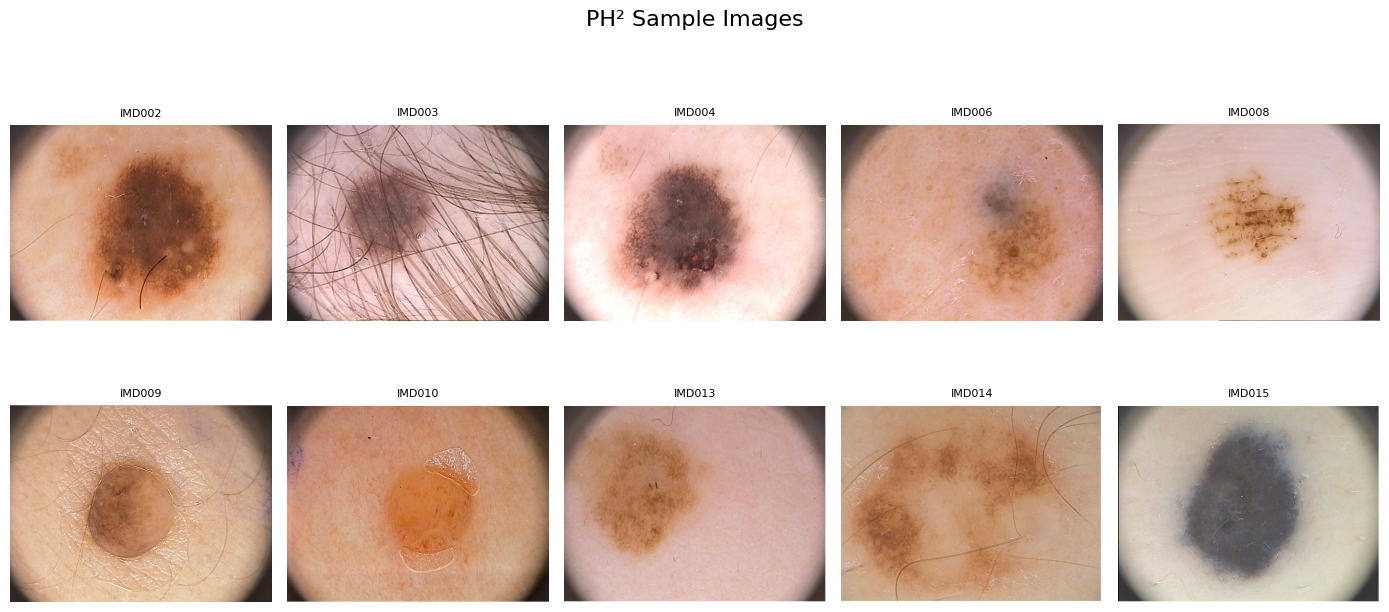

In [56]:

## Display sample PH² images
##

print("=" * 130)
print(f"{'Sample PH² Images':^67}")
print("=" * 130, "\n")

display_files = dermoscopic_files[:10]

fig, axs = plt.subplots(2, 5, figsize=(14, 7))

for ax, image_path in zip(axs.flatten(), display_files):
    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(image_path.parent.parent.name, fontsize=8)
    ax.axis('off')

for ax in axs.flatten()[len(display_files):]:
    ax.axis('off')

fig.suptitle("PH² Sample Images", size=16)
plt.tight_layout()
plt.show()

## Section 2: Diagnostic metadata

### 2.1 Load metadata

The diagnostic metadata is loaded from `PH2_dataset.txt`.

In [57]:

## Load PH² diagnostic metadata
##

metadata_file = PH2_ROOT / "PH2_dataset.txt"

ph2_df = pd.read_csv(
    metadata_file,
    sep="|",
    skipinitialspace=True
)

ph2_df.columns = ph2_df.columns.str.strip()

print("=" * 67)
print(f"{'PH² diagnostic metadata':^67}")
print("=" * 67, "\n")

print(f"Records : {len(ph2_df)}")
print("\nColumns:")
print(ph2_df.columns.tolist())


                      PH² diagnostic metadata                      

Records : 220

Columns:
['Unnamed: 0', 'Unnamed: 1', 'Name', 'Unnamed: 3', 'Histological Diagnosis', 'Unnamed: 5', 'Clinical Diagnosis', 'Unnamed: 7', 'Asymmetry', 'Pigment Network', 'Dots/Globules', 'Streaks', 'Regression Areas', 'Blue-Whitish Veil', 'Unnamed: 14', 'Colors', 'Unnamed: 16', 'Unnamed: 17']


### 2.2 Clinical diagnosis


In [58]:
## Inspect PH² clinical diagnosis
##

print("=" * 67)
print(f"{'PH² clinical diagnosis':^67}")
print("=" * 67, "\n")

print(
    ph2_df["Clinical Diagnosis"]
    .value_counts(dropna=False)
    .sort_index()
)



                      PH² clinical diagnosis                       

Clinical Diagnosis
0.0    80
1.0    80
2.0    40
NaN    20
Name: count, dtype: int64


### 2.3 Diagnostic cases

The 20 rows without a clinical diagnosis are excluded. The remaining case IDs are checked against the 200 image folders in Section 3.

In [59]:
## Keep PH² cases with a clinical diagnosis
##

ph2_df = ph2_df.dropna(
    subset=["Clinical Diagnosis"]
).copy()

ph2_df["Clinical Diagnosis"] = (
    ph2_df["Clinical Diagnosis"]
    .astype(int)
)

print("=" * 67)
print(f"{'PH² diagnostic class distribution':^67}")
print("=" * 67, "\n")

print(f"Diagnostic cases : {len(ph2_df)}")

print("\nClinical diagnosis:")
print(
    ph2_df["Clinical Diagnosis"]
    .value_counts()
    .sort_index()
)

print("\n0 = Common Nevus")
print("1 = Atypical Nevus")
print("2 = Melanoma")

                 PH² diagnostic class distribution                 

Diagnostic cases : 200

Clinical diagnosis:
Clinical Diagnosis
0    80
1    80
2    40
Name: count, dtype: int64

0 = Common Nevus
1 = Atypical Nevus
2 = Melanoma


### 2.4 External evaluation label

Melanoma is encoded as 1. Common and atypical nevi are encoded as 0.

In [60]:
## Create the external evaluation label
##

ph2_df["evaluation_label"] = (
    ph2_df["Clinical Diagnosis"] == 2
).astype(int)

print("=" * 67)
print(f"{'PH² external evaluation labels':^67}")
print("=" * 67, "\n")

print("0 = Non-melanoma")
print("1 = Melanoma")

print("\nEvaluation class distribution:")
print(
    ph2_df["evaluation_label"]
    .value_counts()
    .sort_index()
)

                  PH² external evaluation labels                   

0 = Non-melanoma
1 = Melanoma

Evaluation class distribution:
evaluation_label
0    160
1     40
Name: count, dtype: int64


## Section 3: Data consistency

### 3.1 Metadata and image IDs

The metadata IDs are compared with the image folder IDs.

In [61]:
## Check PH² metadata and image IDs
##

metadata_ids = ph2_df["Name"].astype(str).str.strip()

image_ids = pd.Series(
    [folder.name for folder in image_folders],
    dtype="string"
)

metadata_only = metadata_ids[~metadata_ids.isin(image_ids)].drop_duplicates()
image_only = image_ids[~image_ids.isin(metadata_ids)].drop_duplicates()

print("=" * 67)
print(f"{'PH² metadata and image ID check':^67}")
print("=" * 67, "\n")

print(f"Metadata IDs               : {metadata_ids.nunique()}")
print(f"Image folder IDs           : {image_ids.nunique()}")
print(f"Metadata IDs without images: {len(metadata_only)}")
print(f"Image IDs without metadata : {len(image_only)}")

if len(metadata_only) == 0 and len(image_only) == 0:
    print("\nID check passed: metadata and image folders contain the same cases.")
else:
    print("\nID check failed.")
    raise ValueError("PH² metadata and image IDs do not match.")




                  PH² metadata and image ID check                  

Metadata IDs               : 200
Image folder IDs           : 200
Metadata IDs without images: 0
Image IDs without metadata : 0

ID check passed: metadata and image folders contain the same cases.


## Section 4: Save prepared metadata

The prepared evaluation metadata is saved for later use.

In [62]:
## Save prepared PH² metadata
##

prepared_metadata_file = PH2_BASE / "ph2_prepared.csv"

ph2_df[
    ["Name", "Clinical Diagnosis", "evaluation_label"]
].to_csv(
    prepared_metadata_file,
    index=False
)

saved_metadata = pd.read_csv(prepared_metadata_file)

print("=" * 67)
print(f"{'PH² metadata saved':^67}")
print("=" * 67, "\n")

print(f"Rows saved: {len(saved_metadata)}")
print(f"Missing values: {saved_metadata.isna().sum().sum()}")
print(f"File: {prepared_metadata_file}")

if len(saved_metadata) != 200:
    raise ValueError(
        f"Expected 200 rows, found {len(saved_metadata)}."
    )

if saved_metadata.isna().any().any():
    raise ValueError("Missing values found in saved metadata.")

                        PH² metadata saved                         

Rows saved: 200
Missing values: 0
File: /content/drive/MyDrive/Dissertation_Data/PH2/ph2_prepared.csv


## Section 5: Conclusion

PH² has been prepared for external evaluation. The 200 diagnostic records match the 200 image cases.

The evaluation label separates melanoma from the two nevus categories. PH² will be used for inference only and will not be used for training or model selection.

The mapping from the main model predictions to the PH² binary evaluation will be defined during evaluation.